# Figure 3 — the dense transition

Train a block-sparse network until it stabilizes, then flip its connection
masks to all-ones so the cross-task weights become trainable. Those weights are
already exactly zero, so the flip does not change the function the network
computes — only which weights gradients can reach.

This separates two explanations for the gap in Figure 1. If dense networks
merely fail to *find* the block-sparse solution, then handing one that solution
and continuing should be harmless. It is not: performance degrades shortly
after the new connections appear, and at its own best step-size it eventually
falls below the plain dense network. That is what points at credit assignment
rather than an unlucky optimization path.

16-task multi-MNIST, 256 hidden units, one task re-permuted every 125 steps,
30 seeds. Produced by `experiments/sweeps/02_dense_transition/`.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multi_mnist.analysis import (
    asymptotic_metric, fetch_per_seed_arrays, filter_sweep, filter_to_best,
    get_color_palette, label_curves_inline, load_export, measure_inline_labels,
    normalize_columns, plot_ci_curve, plot_sensitivity, save_fig, set_style,
    stack_per_seed,
)

%matplotlib inline


In [25]:
# The Comet project the published runs live in. Change it if you
# re-run the sweeps into your own project.
PROJECT = 'paper-weight-pruning-scaling-sweep'

# Both this repository's sweep name and the names the published runs were
# logged under, so the figure regenerates from either.
SWEEP_NAMES = [
    '03_dense_transition_n16_h256',                     # this repo
    '00_block_sparse_dense_fill_main_n16_h256',         # published runs
    '00_block_sparse_dense_fill_main_n16_h256_lrext',   # its step-size addendum
]

CELL_COLS = ['task.n_tasks', 'model.initial_hidden_units',
             'algorithm.transition_step', 'seed_offset', 'optimizer.learning_rate']

# The transition step is the method axis. 600,000 exceeds total_steps, so the
# fill never fires and the run is the block-sparse baseline.
NEVER = 600_000
TRANSITION = 250_000
METHOD_LABELS = {0: 'Dense', TRANSITION: 'Dense Transition', NEVER: 'Block-Sparse'}
PALETTE = get_color_palette(classes=list(METHOD_LABELS.values()))
N_TASKS = 16


In [26]:
# Run once to fetch from Comet, then leave commented out.
# from multi_mnist.analysis import download_project
# download_project(PROJECT, output_dir='data')

cfg_all, run_all = load_export(PROJECT, data_dir='data')
cfg_all = normalize_columns(cfg_all)

cfg, run = filter_sweep(cfg_all, run_all, SWEEP_NAMES, cell_cols=CELL_COLS)
run['loss_per_task'] = run['loss'] / N_TASKS
print(f'{len(cfg)} trials after dedupe')
print(cfg.groupby(['algorithm.transition_step', 'seed_offset']).size())


42 trials after dedupe
algorithm.transition_step  seed_offset
0.0                        0.0            7
                           15.0           7
250000.0                   0.0            7
                           15.0           7
600000.0                   0.0            7
                           15.0           7
dtype: int64


## Best step-size per method

In [27]:
best_cfg, best_run, best = filter_to_best(
    cfg, run, ['algorithm.transition_step'], 'accuracy', direction='max')

summary = best.copy()
summary['Method'] = summary['algorithm.transition_step'].map(METHOD_LABELS)
summary['step-size'] = summary['optimizer.learning_rate'].apply(
    lambda v: f'2^{int(np.log2(v))}')
print(summary[['Method', 'step-size', '_metric']].to_string(index=False))

assets = fetch_per_seed_arrays(best_cfg['run_id'].tolist(),
                               cache_dir='data/per_seed_cache')


          Method step-size  _metric
           Dense     2^-11 0.512681
Dense Transition     2^-10 0.479651
    Block-Sparse      2^-8 0.860443


fetch per-seed:   0%|          | 0/6 [00:00<?, ?it/s]

## Figure 3 (left) — learning curves

Four curves. Three are each method at its own best step-size. The fourth is
dense-transition run at the step-size that won for *block-sparse*, which
isolates the effect of the mask flip from any step-size re-tuning the
transition was allowed: it tracks block-sparse exactly until the flip, then
diverges within a few thousand steps.

The dotted vertical line marks the flip.


fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

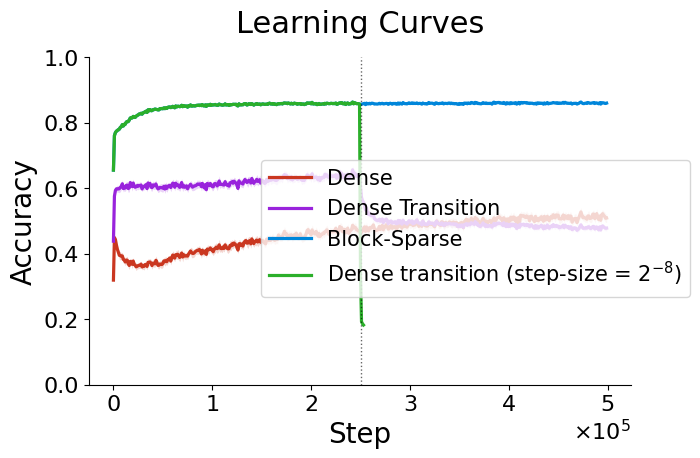

In [28]:
set_style('2-col')
fig, ax = plt.subplots()

for fill_step in sorted(best_cfg['algorithm.transition_step'].unique()):
    rids = best_cfg[best_cfg['algorithm.transition_step'] == fill_step]['run_id'].tolist()
    losses, accs = stack_per_seed(assets, rids)
    if accs is None:
        continue
    method = METHOD_LABELS[int(fill_step)]
    steps = np.arange(accs.shape[0]) * 1000
    plot_ci_curve(steps, accs, label=method, color=PALETTE[method], ax=ax)

# Dense transition at the block-sparse step-size. Numeric columns arrive from
# the CSV as objects, so coerce before comparing.
lr_bs = float(best.loc[best['algorithm.transition_step'] == NEVER,
                       'optimizer.learning_rate'].iloc[0])
cfg_lr = pd.to_numeric(cfg['optimizer.learning_rate'], errors='coerce')
cfg_ts = pd.to_numeric(cfg['algorithm.transition_step'], errors='coerce')
matched = cfg[(cfg_ts == TRANSITION) & (np.abs(cfg_lr - lr_bs) < lr_bs * 1e-6)]
matched_rids = matched['run_id'].tolist()

matched_assets = fetch_per_seed_arrays(matched_rids, cache_dir='data/per_seed_cache')
_, matched_accs = stack_per_seed(matched_assets, matched_rids)
if matched_accs is not None:
    steps = np.arange(matched_accs.shape[0]) * 1000
    plot_ci_curve(steps, matched_accs, color=get_color_palette()[2],
                  label=f'Dense transition (step-size = $2^{{{int(np.log2(lr_bs))}}}$)',
                  ax=ax)

ax.axvline(TRANSITION, linestyle=':', color='black', alpha=0.6, linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves'); ax.set_ylim(0, 1.0)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
fig.legend(loc='center right')
save_fig(fig_dir='../figures/generated', name='fig3_dense_transition_curves')
plt.show()


## Figure 3 (right) — step-size sensitivity

All three methods behave alike up to 2^-11. Block-sparse pulls ahead at 2^-10
and keeps improving past it, while dense and dense-transition diverge — they
distribute each error over more weights, so their effective step-size is larger
at the same step-size parameter, and they hit the stability limit sooner.

Dense and dense-transition diverged above 2^-10, which is why their lines stop.


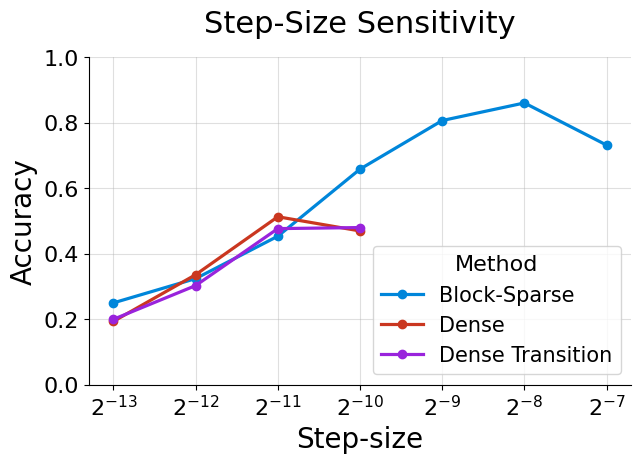

In [29]:
asym = asymptotic_metric(cfg, run, 'accuracy', ['algorithm.transition_step'])
asym['Method'] = asym['algorithm.transition_step'].map(METHOD_LABELS)

set_style('2-col')
fig, ax = plt.subplots()
plot_sensitivity(
    asym, ax=ax, hue_col='Method',
    palette=[PALETTE[m] for m in sorted(asym['Method'].dropna().unique())],
    title='Step-Size Sensitivity', ylabel='Accuracy', ylim=(0, 1),
    legend_title=None)
save_fig(fig_dir='../figures/generated', name='fig3_dense_transition_sensitivity')
plt.show()


# Figure 3b — which direction does the damage

Everything above is unchanged. What follows repeats it with one more arm.

The transition hurts, but a new cross-task connection hurts in two directions
at once. Forward, it feeds another task's signal into a hidden unit and into
an output. Backward, a new `W2` connection returns another task's error to a
hidden unit, so that unit's incoming weights are now trained on a loss that is
not its own.

The **forward-only** arm removes the second one. The connections the flip adds
still run in the forward pass and still learn their own weights; they simply
send no error back into the hidden layer. Whatever degradation survives is the
forward channel, and the gap to the ordinary transition at the same step-size
is the backward one.

Produced by `experiments/sweeps/02_dense_transition/sweep/forward_only.yaml`.
That is not a sweep — it is the two step-sizes Figure 3 already plots the
transition at, 2⁻¹⁰ (the transition's own best) and 2⁻⁸ (block-sparse's), at
the same 30 seeds. Re-run `download_project` in the load cell above before
running this section, or the new sweep will not be in the export.


In [30]:
from multi_mnist.analysis import dedupe_trials

FORWARD_ONLY_SWEEP = '03_dense_transition_forward_only_n16_h256'
FORWARD_ONLY = 'Forward-Only Transition'
FO_COL = 'algorithm.forward_only_distractors'


def add_method_column(cfg):
    """Label each trial by arm.

    The forward-only runs share their `transition_step` with the ordinary
    ones, so the flag has to join the key or the two collapse into one cell.
    Runs from before the flag existed have no column at all.
    """
    out = cfg.copy()
    flag = (out[FO_COL].astype(str).str.lower().isin(['true', '1', '1.0'])
            if FO_COL in out.columns else pd.Series(False, index=out.index))
    out['Method'] = pd.to_numeric(
        out['algorithm.transition_step'], errors='coerce').map(METHOD_LABELS)
    out.loc[flag, 'Method'] = FORWARD_ONLY
    return out


# CELL_COLS with Method standing in for the transition step.
CELL_COLS_FO = ['task.n_tasks', 'model.initial_hidden_units',
                'Method', 'seed_offset', 'optimizer.learning_rate']

# Every method keeps its pinned color. Slot 2 already labels the
# step-size-matched transition curve in Figure 3, so the new arm takes 4.
PALETTE_FO = dict(PALETTE)
PALETTE_FO[FORWARD_ONLY] = get_color_palette()[4]


In [31]:
cfg_fo, run_fo = filter_sweep(
    cfg_all, run_all, SWEEP_NAMES + [FORWARD_ONLY_SWEEP], dedup=False)
cfg_fo = add_method_column(cfg_fo)
cfg_fo, run_fo = dedupe_trials(cfg_fo, run_fo, CELL_COLS_FO)
run_fo['loss_per_task'] = run_fo['loss'] / N_TASKS
print(f'{len(cfg_fo)} trials after dedupe')
print(cfg_fo.groupby(['Method', 'seed_offset']).size())


54 trials after dedupe
Method                   seed_offset
Block-Sparse             0.0            7
                         15.0           7
Dense                    0.0            7
                         15.0           7
Dense Transition         0.0            7
                         15.0           7
Forward-Only Transition  0.0            2
                         5.0            2
                         10.0           2
                         15.0           2
                         20.0           2
                         25.0           2
dtype: int64


## Best step-size per method

The forward-only arm only ran at two step-sizes, so its "best" is a choice
between those two rather than a swept optimum.


In [32]:
best_cfg_fo, best_run_fo, best_fo = filter_to_best(
    cfg_fo, run_fo, ['Method'], 'accuracy', direction='max')

summary_fo = best_fo.copy()
summary_fo['step-size'] = summary_fo['optimizer.learning_rate'].apply(
    lambda v: f'2^{int(np.log2(float(v)))}')
print(summary_fo[['Method', 'step-size', '_metric']].to_string(index=False))

assets_fo = fetch_per_seed_arrays(best_cfg_fo['run_id'].tolist(),
                                  cache_dir='data/per_seed_cache')


                 Method step-size  _metric
           Block-Sparse      2^-8 0.860443
                  Dense     2^-11 0.512681
       Dense Transition     2^-10 0.479651
Forward-Only Transition     2^-10 0.565804


fetch per-seed:   0%|          | 0/12 [00:00<?, ?it/s]

## Figure 3b (left) — learning curves

The four curves of Figure 3, plus the forward-only arm at its own best
step-size — which is 2⁻¹⁰, the same cell the ordinary transition wins at, so
the two transition arms sit side by side and the gap between them after the
flip is the backward channel on its own.

Forward-only at 2⁻⁸ is not drawn: it diverges within 6,000 steps of the flip,
so its cell is null and the curve would stop at the dotted line.

The dotted vertical line marks the flip.


fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

fetch per-seed:   0%|          | 0/6 [00:00<?, ?it/s]

fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

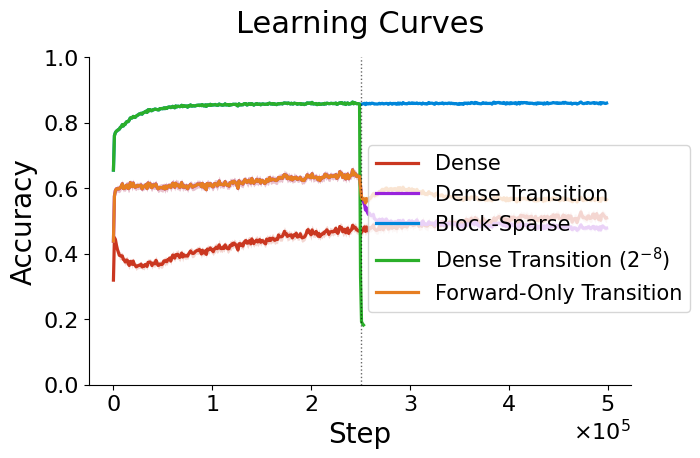

In [33]:
set_style('2-col')
fig, ax = plt.subplots()

# Numeric columns arrive from the CSV as objects, so coerce before comparing.
lr_bs = float(best_fo.loc[best_fo['Method'] == METHOD_LABELS[NEVER],
                          'optimizer.learning_rate'].iloc[0])
cfg_lr_fo = pd.to_numeric(cfg_fo['optimizer.learning_rate'], errors='coerce')


def _accs(run_ids):
    _, accs = stack_per_seed(
        fetch_per_seed_arrays(run_ids, cache_dir='data/per_seed_cache'), run_ids)
    return accs


# Each arm at its own best step-size, plus the ordinary transition re-run at
# block-sparse's step-size -- the curve that isolates the flip from any
# step-size re-tuning. Forward-only's own best is the same cell the ordinary
# transition wins at, so those two are directly comparable.
PAPER_CURVES = []
for method in (METHOD_LABELS[0], METHOD_LABELS[TRANSITION], METHOD_LABELS[NEVER],
               FORWARD_ONLY):
    rids = best_cfg_fo[best_cfg_fo['Method'] == method]['run_id'].tolist()
    PAPER_CURVES.append((method, _accs(rids), PALETTE_FO[method]))

matched_rids = cfg_fo[(cfg_fo['Method'] == METHOD_LABELS[TRANSITION])
                      & (np.abs(cfg_lr_fo - lr_bs) < lr_bs * 1e-6)]['run_id'].tolist()
PAPER_CURVES.insert(3, (
    f'Dense Transition ($2^{{{int(np.log2(lr_bs))}}}$)',
    _accs(matched_rids), get_color_palette()[2]))

for label, accs, color in PAPER_CURVES:
    if accs is None:
        continue
    plot_ci_curve(np.arange(accs.shape[0]) * 1000, accs,
                  label=label, color=color, ax=ax)

ax.axvline(TRANSITION, linestyle=':', color='black', alpha=0.6, linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves'); ax.set_ylim(0, 1.0)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
fig.legend(loc='center right')
save_fig(fig_dir='../figures/generated', name='fig3b_forward_only_curves')
plt.show()


## Paper figures

The two panels that go in the paper. Saved to `figures/generated`; the PDFs
are then copied flat into `figures/paper/` alongside the other `paper_fig*`
files, which is how that directory is populated.

The curves panel is the figure above. The sensitivity panel is Figure 3's,
unchanged — the forward-only arm ran at two step-sizes rather than a swept
range, so it has no sensitivity curve to show and is left out of that panel.

Five curves reach into every corner of the left panel, so its legend sits
above the axes under the title rather than inside, as the `paper_fig5` panels
do.


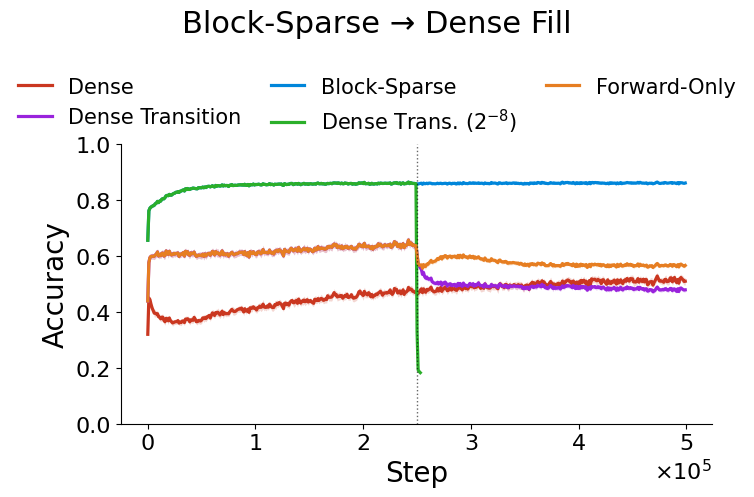

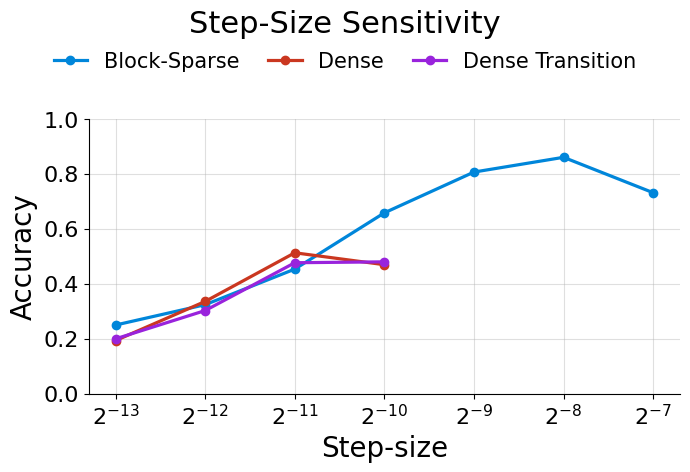

In [34]:
FIG_DIR = '../figures/generated'
LEGEND_KW = dict(loc='upper center', bbox_to_anchor=(0.5, 1.045), ncol=3,
                 frameon=False, handlelength=1.6, columnspacing=1.4)

# Shorter legend labels, in the order PAPER_CURVES was built: at 2-column
# width the full names make the legend wider than the axes it sits over.
PAPER_LABELS = ['Dense', 'Dense Transition', 'Block-Sparse',
                f'Dense Trans. ($2^{{{int(np.log2(lr_bs))}}}$)', 'Forward-Only']

# Left panel: learning curves, including the forward-only arm.
set_style('2-col')
fig, ax = plt.subplots()
for (_, accs, color), label in zip(PAPER_CURVES, PAPER_LABELS):
    if accs is None:
        continue
    plot_ci_curve(np.arange(accs.shape[0]) * 1000, accs,
                  label=label, color=color, ax=ax)
ax.axvline(TRANSITION, linestyle=':', color='black', alpha=0.6, linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.0)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, **LEGEND_KW)
# No `rect` on tight_layout: the legend is anchored outside the axes and
# save_fig crops with bbox_inches='tight', so reserving space inside as well
# would leave a band of white between the legend and the plot. suptitle
# defaults to figure.titlesize; the other paper figures title with
# ax.set_title, so match axes.titlesize to keep the sizes consistent.
fig.suptitle('Block-Sparse → Dense Fill', y=1.16,
             fontsize=plt.rcParams['axes.titlesize'])
fig.tight_layout()
save_fig('paper_fig3_curves', fig_dir=FIG_DIR)
plt.show()

# Right panel: Figure 3's sensitivity, three methods, unchanged.
set_style('2-col')
fig, ax = plt.subplots()
plot_sensitivity(
    asym, ax=ax, hue_col='Method',
    palette=[PALETTE[m] for m in sorted(asym['Method'].dropna().unique())],
    ylabel='Accuracy', ylim=(0, 1), legend_title=None)
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, **LEGEND_KW)
fig.suptitle('Step-Size Sensitivity', y=1.10,
             fontsize=plt.rcParams['axes.titlesize'])
fig.tight_layout()
save_fig('paper_fig3_sensitivity', fig_dir=FIG_DIR)
plt.show()


### Paper-ready curves, labelled inline

The same panel with its legend replaced by inline labels, in the style of
`figures/paper_edited`. Two versions: the figure as originally published, and
the same with the forward-only arm added.

In [ ]:
# (text, x, side, optional smaller parenthetical) for each arm. The label
# positions are the only hand-set numbers; `label_curves_inline` works out the
# heights so every label ends up the same clearance from its own curve.
CURVE_LABELS = {
    METHOD_LABELS[0]:          ('Dense', 0.15e5, 'below', None),
    METHOD_LABELS[TRANSITION]: ('Dense transition', 0.16e5, 'above', None),
    METHOD_LABELS[NEVER]:      ('Block-sparse', 3.7e5, 'above', None),
    PAPER_CURVES[3][0]:        ('Dense transition', 0.17e5, 'above',
                                f'(step-size = $2^{{{int(np.log2(lr_bs))}}}$)'),
    FORWARD_ONLY:              ('Dense-transition (FO)', 3.05e5, 'above', None),
}


def plot_fig3_curves(savename, forward_only):
    """Figure 3's left panel, labelled inline. `forward_only` adds the fifth arm."""
    curves = [c for c in PAPER_CURVES if forward_only or c[0] != FORWARD_ONLY]
    # Forward-only is drawn first so the ordinary transition sits on top of it:
    # the two are the same run until the flip, and the panel is about where they
    # part, which the arm underneath would otherwise hide.
    curves.sort(key=lambda c: c[0] != FORWARD_ONLY)

    set_style('2-col')
    fig, ax = plt.subplots()
    for _, accs, color in curves:
        plot_ci_curve(np.arange(accs.shape[0]) * 1000, accs, color=color, ax=ax)
    ax.axvline(TRANSITION, linestyle=':', color='black', alpha=0.6, linewidth=1)
    ax.set_xlabel('Step'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.0)
    # The x axis runs exactly as far as the runs do, as in the other panels.
    ax.set_xlim(0, max(len(a) for _, a, _ in curves) * 1000)
    ax.set_title('Learning Curves')
    ax.grid(True); ax.set_axisbelow(True)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    fig.tight_layout()

    specs = []
    for name, accs, color in curves:
        text, x, side, sub = CURVE_LABELS[name]
        mean = accs.mean(axis=1)
        keep = ~np.isnan(mean)          # the 2^-8 arm diverges and its curve stops
        curve = (np.arange(len(mean))[keep] * 1000, mean[keep])
        specs.append((text, x, side, color, curve, sub) if sub
                     else (text, x, side, color, curve))
    texts = label_curves_inline(ax, specs)
    print(savename, measure_inline_labels(ax, specs, texts))

    # No legend to strip, so this writes one file per format rather than
    # save_fig's pair.
    for fmt in ('pdf', 'png'):
        fig.savefig(f'{FIG_DIR}/{fmt}/{savename}.{fmt}', bbox_inches='tight', dpi=400)
    plt.show()


plot_fig3_curves('paper_fig3_curves_labeled', forward_only=False)
plot_fig3_curves('paper_fig3_curves_fo_labeled', forward_only=True)